In [2]:
import numpy as np
import torch
from data_aware_dp import sampling 
from matplotlib import pyplot as plt


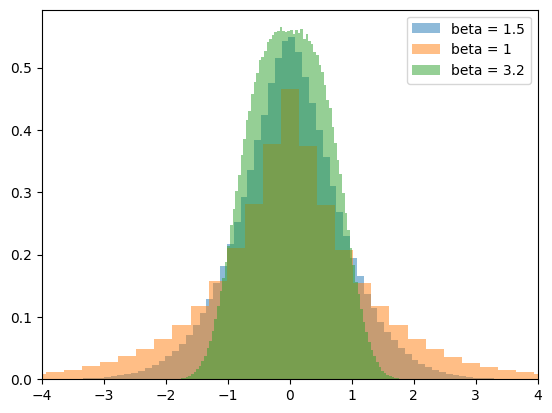

In [9]:
def scale_from_c(c, beta):
    return 1 / (c**(1 / beta))

def exponential_power_sampler(beta, scale, seed=0):
    """ EPD sampler - taken from https://github.com/scipy/scipy/blob/v1.10.1/scipy/stats/_continuous_distns.py#L9398-L9482
    exp(-scale * |x|**beta)
    (note: see equation 9 from https://sci-hub.ru/https://doi.org/10.1080/00949650802290912)
    """
    # see [2]_ for the algorithm
    # see [3]_ for reference implementation in SAS

    a = 1 / beta
    b = np.power(scale, beta)
    rng = np.random.Generator(np.random.SFC64(seed))
    # make it faster
    def f(size=1.):
        """ Sample from the EPD distribution.
        exp(-scale * |x|**beta)
        
        # see equation 9 from https://sci-hub.ru/https://doi.org/10.1080/00949650802290912
        """
        z = rng.gamma(shape=a, scale=b, size=size)
        #z = np.random.gamma(1/beta, size=size)
        y = np.power(z, (1 / beta))
        # convert y to array to ensure masking support
        #y = np.asarray(y)
        mask = rng.random(size=y.shape) < 0.5
        y[mask] *= -1  #y[mask]
        return y
    return f


def beta_exponential_sampler(beta, c):
    """ 
    return sampler from beta exponential distribution (function can be called with no arguments or with size = # argument)
    
    exp(-scale * |x|**beta)
    """
    scale = scale_from_c(c=c, beta=beta)
    return exponential_power_sampler(beta=beta, scale=scale)

# plot histogram from beta exponential distribution
beta = 1.5
c = 1
N = int(1e6)
sampler = beta_exponential_sampler(beta=beta, c=c)
samples = sampler(N)
plt.hist(samples, bins=100, density=True, label=f'beta = {beta}', alpha=0.5)
beta = 1
sampler = beta_exponential_sampler(beta=beta, c=c)
samples = sampler(N)
plt.hist(samples, bins=100, density=True, label=f'beta = {beta}', alpha=0.5)
beta = 3.2
sampler = beta_exponential_sampler(beta=beta, c=c)
samples = sampler(N)
plt.hist(samples, bins=100, density=True, label=f'beta = {beta}', alpha=0.5)
plt.legend()
plt.xlim(-4,4)
plt.show()


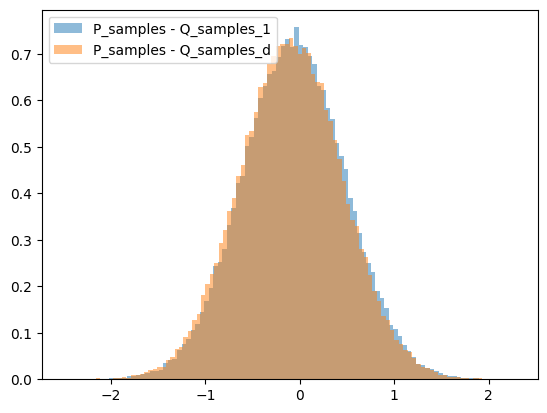

In [5]:
def P(beta, d , N ,sampler):
    samples = sampler(N* d)
    samples = samples.reshape(N, d)
    sample_norms = np.linalg.norm(samples, axis=1, ord=beta)
    return sample_norms

def Q(beta, d, N, mu, sampler):
    samples = sampler(N* d)
    samples = samples.reshape(N, d)
    # subtract each sample from mu
    samples = samples - mu
    sample_norms = np.linalg.norm(samples, axis=1, ord=beta)
    return sample_norms

def mu_1(d):
    mu = np.zeros(d) # one hot
    mu[0] = 1
    return mu

def mu_d(d):
    mu = np.ones(d)
    mu = mu / np.linalg.norm(mu, ord=beta)
    return mu 

N = int(1e5)
beta = 2.2
c = 1

d = 100
sampler = beta_exponential_sampler(beta=beta, c=c) # this is X


P_samples = P(beta, d, N, sampler  )
Q_samples_1 = Q(beta, d, N, mu_1(d), sampler)
Q_samples_d = Q(beta, d, N, mu_d(d), sampler)

# plot histogram of P_samples - Q_samples_1
plt.hist(P_samples - Q_samples_1, bins=100, density=True, label='P_samples - Q_samples_1', alpha=0.5)
plt.hist(P_samples - Q_samples_d, bins=100, density=True, label='P_samples - Q_samples_d', alpha=0.5)
plt.legend()
plt.show()



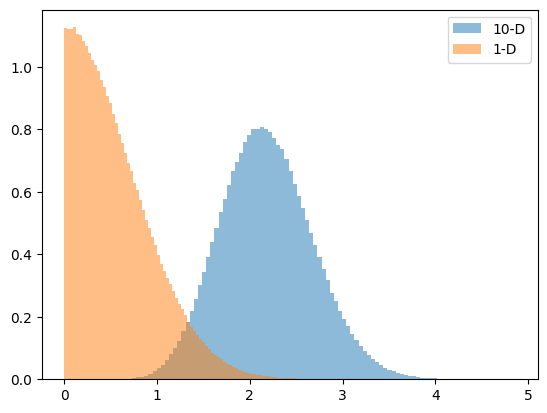

In [ ]:
N = int(1e6)
d = 10
# d dimensional generalized gaussian


beta,c = 2,1

sampler = sampling.beta_exponential_sampler(beta=beta, c=c) # this is X


samples_d = sampler(N*d)
samples_d = samples_d.reshape(N, d)

samples_1 = sampler(N)
samples_1 = samples_1.reshape(N, 1)


# take l-beta norm
sample_d_norms = np.linalg.norm(samples_d, axis=1, ord=beta)
sample_d_norms.shape
#sample_1_norms = np.linalg.norm(samples_1, axis=1, ord=beta) # just the absolute value
sample_1_norms = np.linalg.norm(samples_1, axis=1, ord=beta)

plt.hist(sample_d_norms, bins=100, density=True, label=f'{d}-D', alpha=0.5) 
plt.hist(sample_1_norms, bins=100, density=True, label='1-D', alpha=0.5)
plt.legend()
plt.show()

